# **Experiment Notebook**



In [81]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [82]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Import Packages

In [84]:
# Install custom package
!pip install -i https://test.pypi.org/simple/ my_krml_14635775==2025.0.2.0

Looking in indexes: https://test.pypi.org/simple/


In [85]:
# <Student to fill this section>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
import math
from sklearn.model_selection import GridSearchCV

# custom package
from my_krml_14635775.data import data_quality, duplicate_values, missing_values, sets
from my_krml_14635775.features import height, selection_point_biserial
from my_krml_14635775.models.performance import binary_class_pred_eval



---
## A. Project Description


In [86]:
# <Student to fill this section>
student_name = "Larry Augusto Iglesias de Souza"
student_id = "14635775"
group_id = "group23"

In [87]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [88]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [89]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [90]:
# <Student to fill this section>
business_use_case_description = """
This project aims to develop a machine learning model that estimates the likelihood of a player being drafted to the NBA, with outputs in the form of a probability score based on historical and current performance statistics, player attributes, and background information.
"""

In [91]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [92]:
# <Student to fill this section>
business_objectives = """
Accurate predictions will support NBA teams in optimising scouting decisions, help agents in guiding players' career strategies, and assist colleges in enhancing player development and recruitment. Incorrect results bring risks such as wasted investments and missed opportunities.
"""

In [93]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [94]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
NBA scouts and team managers being the primary users for decision making through predictions. Sports agents and coaches assess player's value and help guiding training focus by identifying player's gap. Media channels can have access to early talented players discovery, and athletes being directly impacted have a better understanding of their own weaknesses, strengths and future prospect.
"""

In [95]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [96]:
# <Student to fill this section>
df = pd.read_csv('../data/raw/train.csv')
X_test = pd.read_csv('../data/raw/test.csv')

### C.2 Define Target variable

In [97]:
# <Student to fill this section>
df['drafted']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
14769    0.0
14770    0.0
14771    0.0
14772    0.0
14773    0.0
Name: drafted, Length: 14774, dtype: float64

In [98]:
# <Student to fill this section>
target_definition_explanations = """
The objective is to predict whether a player will be drafted into the NBA, represented as a binary classification problem where the target variable 'drafted' indicates if a player was selected (1) or not (0) in the NBA draft.
"""

In [99]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [100]:
# <Student to fill this section>

target_name = 'drafted'

### C.4 Explore Target variable

In [101]:
# <Student to fill this section>
target_distribution_explanations = """
No exploration needed due to insights from experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). In the dataset, there are 14774 registers for the target variable containing values of 0 and 1 only, meaning there is no missing values or inconsistencies for the target variable. The distribution is highly imbalanced with only 0.8% of the data being of drafted players, which indicates the need for appropriate evaluation metrics such as ROC AUC over simple accuracy. Also, the target variable shows good relationships with numerical features such as GP, Min_per and Rec_Rank. More EDA should be done to understand relationship with categorical features, and validate possible outliers.
"""

In [102]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<Explore dataset\>`

In [103]:
# <Student to fill this section>
feature_1_insights = """
Exploration already done in experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). Through descriptive analysis on the dataset, problems like inconsistency, incorrect format and outliers were found (e.g. columns adrtg, ht and USG). Also, the big difference of values in the features may suggest the need for feature scaling later on. From correlation matrix was possible to identify possible redundant or leakage features (e.g. Min_per against MP with 0.97 points of correlation, and porpag against pts); Some features (e.g. pts, stops and stl) are highly positive correlated with minutes played features, since the time of a player on the game influence directly on the quantity of times those actions are made. The dataset contains many missing values with some features reaching up to 66.91% of missing values in the whole dataset. 2462 duplicated rows were found, and many features showed skewness problems (e.g. ast, stl, pts). Further analysis on specific features must be made to understand issues in details, and problems found in this EDA may or may not be fixed in this experiment depending on the need for so.
"""

In [104]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<ht\>`

In [105]:
# <Student to fill this section>
feature_2_insights = """
Exploration already done in experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). Height (ht) is a critical attribute in basketball, often influencing a player's position and role on the team. The dataset shows a wide range of heights, with values appearing as date instead of height measurement system, which shows inconsistency and incorrect format. This suggests potential data entry errors and the need for standardisation of height measurements. Addressing these issues is essential for accurate analysis and modelling, as height can significantly impact performance metrics and draft likelihood.
"""

In [106]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `\<year\>`


In [107]:
# <Student to fill this section>
feature_3_insights = """
Exploration already done in experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). Year could possibly be a feature for data splitting since it maintains a healthy historical behaviour simulation. No issues were found in the feature year.
"""

In [108]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest `\<Multiple Featues\>`

> You can add more cells related to other feeatures in this section

In [109]:
# <Student to fill this section>
feature_4_insights = """
Exploration already done in experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). eatures Ortg and Usg show high outliers that are possibly not realistic based on statistics shown in NBA basketabll references website. These outliers may need to be addressed by capping or transformation to ensure they do not negatively influence the model training process. Other features such as eFG, TS_per and ORB_per presents the same behaviour as previously shown in the target exploration step.
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.9 Explore Feature of Interest `\<Multiple Featues 2\>`

In [111]:
# <Student to fill this section>
feature_5_insights = """
Exploration already done in experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). Features pts and blk seams to show incorrect format for values, with both features having decimal values when they should be integers. Correcting these inconsistencies is crucial for reliable performance metrics and draft likelihood predictions. Other features such as stl, ast and treb present the same behaviour.
"""

In [112]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

---
## D. Feature Selection


### D.1 Approach "\<Point_biserial\>"


In [113]:
# <Student to fill this section>
feature_selection_1_insights = """
Exploration already done in experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). Point-biserial correlation analysis was used as approach for feature selection on this experiment. The approach is helpful due to its statistical measurement to quantify the relationship between a binary variable (target) and a continuous variable (features), giving insights about coefficient correlation and its associated p-value. The results show several features with significant correlations to the target variable 'drafted'. Notably, features such as 'dunksmade', 'dunkmiss_dunksmade', 'porpag' and 'twoPM' exhibited strong positive correlations, suggesting that players with higher points made overall are more likely to be drafted. On the other hand, features like 'adrtg' and 'TO_per' showed negative correlations, indicating that lower defensive ratings may decrease draft likelihood. These insights will guide feature selection for model development for next experiments.
"""

In [114]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<describe_approach_here\>"


In [115]:
# <Student to fill this section>

In [116]:
# <Student to fill this section>
feature_selection_2_insights = """
provide an explanation on why you use this approach for feature selection and describe its results
"""

In [117]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [118]:
# <Student to fill this section>

features_list = ["gp", "ortg", "usg", "efg", "ts_per", "to_per", "twopm", "tpm", "ht", "porpag", "adjoe", "dunksmiss_dunksmade", "adrtg", "fta", "stops", "gbpm", "mp", "dreb", "ast", "stl", "blk", "pts"]

In [119]:
# <Student to fill this section>
feature_selection_explanations = """
From experiment 1 (36120-25SP-group23-14635775-AT1-experiment-1). The selected features are based on the point-biserial correlation analysis results, focusing on those with significant correlations to the target variable 'drafted'. This selection aims to balance offensive and defensive attributes, providing a comprehensive view of player performance. Future experiments will also be used as way to validate selected features.
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <Duplication__Missing_Values__Format>

In [121]:
# Removing duplicated rows
df_cleaned = df.drop_duplicates().reset_index(drop=True)

In [122]:
# Transforming columns names to lowercase for easier handling
df_cleaned.columns = df_cleaned.columns.str.lower()
X_test.columns = X_test.columns.str.lower()

In [123]:
# Removing unnecessary columns
df_cleaned = df_cleaned.drop(columns=['team', 'conf', 'yr', 'type', 'player_id'])

In [124]:
# Transforming value format in features with decimals that should be integers

int_columns = ['pts', 'blk', 'stl', 'ast', 'treb', 'dreb', 'oreb']
df_cleaned = data_quality.multiply_decimal(df_cleaned, int_columns)
X_test = data_quality.multiply_decimal(X_test, int_columns)

In [125]:
# Checking for missing values
missing_values.check_missing_values(df_cleaned)

Missing Values Summary:
Column: ht, Missing Count: 7, Missing Percentage: 0.06%
Column: rec_rank, Missing Count: 8240, Missing Percentage: 66.93%
Column: ast_tov, Missing Count: 1284, Missing Percentage: 10.43%
Column: rimmade, Missing Count: 1720, Missing Percentage: 13.97%
Column: rimmade_rimmiss, Missing Count: 1720, Missing Percentage: 13.97%
Column: midmade, Missing Count: 1720, Missing Percentage: 13.97%
Column: midmade_midmiss, Missing Count: 1720, Missing Percentage: 13.97%
Column: rim_ratio, Missing Count: 2672, Missing Percentage: 21.7%
Column: mid_ratio, Missing Count: 2665, Missing Percentage: 21.65%
Column: dunksmade, Missing Count: 1720, Missing Percentage: 13.97%
Column: dunksmiss_dunksmade, Missing Count: 1720, Missing Percentage: 13.97%
Column: dunks_ratio, Missing Count: 7831, Missing Percentage: 63.6%
Column: drtg, Missing Count: 4, Missing Percentage: 0.03%
Column: adrtg, Missing Count: 4, Missing Percentage: 0.03%
Column: dporpag, Missing Count: 4, Missing Percenta

In [126]:
# Atributing mode value to missing values in numerical features with small number of missing values
small_miss_columns = ['pts', 'blk', 'stl', 'ast', 'treb', 'dreb', 'oreb', 'dgbpm', 'ogbpm', 'mp', 'gbpm', 'dbpm', 'obpm', 'bpm', 'stops', 'dporpag', 'adrtg', 'drtg']
df_cleaned = data_quality.fillna_mode(df_cleaned, small_miss_columns)
X_test = data_quality.fillna_mode(X_test, small_miss_columns)

In [127]:
# Atributing median value to missing values in numerical features based on columns "efg" and "ts_per"

shot_col_miss_val = ['rimmade', 'rimmade_rimmiss', 'midmade', 'midmade_midmiss', 'dunksmade', 'dunksmiss_dunksmade']
group_rule = [df_cleaned['efg'].round(), df_cleaned['ts_per'].round()]
group_rule_test = [X_test['efg'].round(), X_test['ts_per'].round()]

df_cleaned = data_quality.fillna_groupby(df_cleaned, shot_col_miss_val, group_rule, transform='median')
X_test = data_quality.fillna_groupby(X_test, shot_col_miss_val, group_rule_test, transform='median')

In [128]:
# Atributing mode value to missing values that were not filled by previous step

df_cleaned = data_quality.fillna_mode(df_cleaned, shot_col_miss_val)
X_test = data_quality.fillna_mode(X_test, shot_col_miss_val)

In [129]:
# Handling missing values to ratio features based on the calculation of made/miss shots
ratio_col_miss_val = ['rim_ratio', 'mid_ratio', 'dunks_ratio']
for col in ratio_col_miss_val:
    if col == 'rim_ratio':
        df_cleaned[col] = np.where(df_cleaned['rimmade'] != 0, df_cleaned['rimmade'] / df_cleaned['rimmade_rimmiss'], 0).round(2) # Handles division by zero
        X_test[col] = np.where(X_test['rimmade'] != 0, X_test['rimmade'] / X_test['rimmade_rimmiss'], 0).round(2)
    elif col == 'mid_ratio':
        df_cleaned[col] = np.where(df_cleaned['midmade'] != 0, df_cleaned['midmade'] / df_cleaned['midmade_midmiss'], 0).round(2) # Handles division by zero
        X_test[col] = np.where(X_test['midmade'] != 0, X_test['midmade'] / X_test['midmade_midmiss'], 0).round(2)
    elif col == 'dunks_ratio':
        df_cleaned[col] = np.where(df_cleaned['dunksmade'] != 0, df_cleaned['dunksmade'] / df_cleaned['dunksmiss_dunksmade'], 0).round(2) # Handles division by zero
        X_test[col] = np.where(X_test['dunksmade'] != 0, X_test['dunksmade'] / X_test['dunksmiss_dunksmade'], 0).round(2)

# Atributing 1 to "inf" values and value higher than 1 in ratio features due to division by zero and unrealistic values from inputs
for col in ratio_col_miss_val:
    df_cleaned[col].replace([np.inf, -np.inf], 1, inplace=True)
    X_test[col].replace([np.inf, -np.inf], 1, inplace=True)
    
    df_cleaned[col] = np.where(df_cleaned[col] > 1, 1, df_cleaned[col]) # Cap values higher than 1 to 1
    X_test[col] = np.where(X_test[col] > 1, 1, X_test[col]) # Cap values higher than 1 to 1

In [130]:
# Atributing mean value to missing values in ast_tov feature based on columns "ast_per" and "to_per"

cols = ['ast_tov']
group_rule = [df_cleaned['ast_per'].round(), df_cleaned['to_per'].round()]
group_rule_test = [X_test['ast_per'].round(), X_test['to_per'].round()]

df_cleaned = data_quality.fillna_groupby(df_cleaned, cols, group_rule, transform='mean')
X_test = data_quality.fillna_groupby(X_test, cols, group_rule_test, transform='mean')

In [131]:
# Atributing mean value to ast_tov missing values that were not filled by previous step
cols = ['ast_tov']
df_cleaned = data_quality.fillna_mean(df_cleaned, cols)
X_test = data_quality.fillna_mean(X_test, cols)

In [132]:
missing_values.check_missing_values(df_cleaned)

Missing Values Summary:
Column: ht, Missing Count: 7, Missing Percentage: 0.06%
Column: rec_rank, Missing Count: 8240, Missing Percentage: 66.93%


In [133]:
# <Student to fill this section>
data_cleaning_1_explanations = """
In this step duplication, missing values and incorrect format was fixed. Duplication was specially important to fix due to redundancy of data, and models will learn same pattern if it stays in the dataset. The missing values were fixed using rules of calculations to simulate real values as much as possible, and features with incorrect format were fix for a better interpretability and standardisation. The feature rec_rank was left of fix for missing values due to lack of business knowledge of how to compute values, and decided to drop the feature due to high volume of missing values.
"""

In [134]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <Max_Min_Values>

In [135]:
# Transforming outliers in numerical features by capping values based on NBA basketball website references (e.g. https://www.statmuse.com/ask/highest-ortg?l=nba)

for df in [df_cleaned, X_test]:
    df['ortg'] = np.where(df['ortg'] > 130, df['ortg'].mean().round(2), df['ortg']) # Capping Ortg to 130
    df['usg'] = np.where(df['usg'] > 35, df['usg'].mean().round(2), df['usg']) # Capping usg to 35
    df['efg'] = np.where(df['efg'] > 50, df['efg'].mean().round(2), df['efg']) # Capping efg to 50
    df['ts_per'] = np.where(df['ts_per'] > 100, df['ts_per'].mean().round(2), df['ts_per']) # Capping ts_per to 100
    df['orb_per'] = np.where(df['orb_per'] > 100, df['orb_per'].mean().round(2), df['orb_per']) # Capping orb_per to 100
    df['drb_per'] = np.where(df['drb_per'] > 100, df['drb_per'].mean().round(2), df['drb_per']) # Capping drb_per to 100
    df['blk_per'] = np.where(df['blk_per'] > 100, df['blk_per'].mean().round(2), df['blk_per']) # Capping blk_per to 100
    df['stl_per'] = np.where(df['stl_per'] > 100, df['stl_per'].mean().round(2), df['stl_per']) # Capping stl_per to 100
    df['ftr'] = np.where(df['ftr'] > 100, df['ftr'].mean().round(2), df['ftr']) # Capping ftr to 100
    df['pfr'] = np.where(df['pfr'] > 100, df['pfr'].mean().round(2), df['pfr']) # Capping pfr to 100
    df['bpm'] = np.where(df['bpm'] > 100, df['bpm'].mean().round(2), df['bpm']) # Capping bpm to 100
    df['obpm'] = np.where(df['obpm'] > 100, df['obpm'].mean().round(2), df['obpm']) # Capping obpm to 100
    df['dbpm'] = np.where(df['dbpm'] > 100, df['dbpm'].mean().round(2), df['dbpm']) # Capping dbpm to 100

In [136]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Features with outliers were capped based on references from NBA basketball statistics website. Features that did not have any reference or business knowledge was left without treatment for outliers. The treatment is specially helpful to avoid models being influenced by extreme values that do not represent real world scenarios, and helps to improve model generalization and performance.
"""

In [137]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <ht>

In [138]:
# Transforming Height from date format to inches
df_cleaned['ht'] = df_cleaned['ht'].apply(height.height_data_cleaning)
X_test['ht'] = X_test['ht'].apply(height.height_data_cleaning)

In [139]:
# <Student to fill this section>
data_cleaning_3_explanations = """
The feature height in the raw data is in date format instead of inches (int), therefore it is necessary to transform it to be able to train the model. The feature could be an important factor for the model performance.
"""

In [140]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.4 Data Transformation "\<Generalization\>"

> You can add more cells related to other issues in this section

In [141]:
# Transforming features with high differences in decimals
cols = ['porpag', 'adjoe', 'ast_tov', 'dporpag', 'bpm', 'obpm', 'dbpm', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'drtg', 'adrtg', 'stops']
df_cleaned[cols] = df_cleaned[cols].round()
X_test[cols] = X_test[cols].round()

In [142]:
# <Student to fill this section>
data_cleaning_4_explanations = """
A transformation on the features with high differences in decimals was made in an attempt to generalize the data, and with that achieve better model performance.
"""

In [143]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_4_explanations', value=data_cleaning_4_explanations)

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"


In [144]:
# <Student to fill this section>

In [145]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [146]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<put_name_here\>"




In [147]:
# <Student to fill this section>

In [148]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [149]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [150]:
# <Student to fill this section>

In [151]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [152]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [153]:
# Splitting dataset by year.
X_train, y_train, X_val, y_val = sets.split_set_by_year(df_cleaned, target_name, 'year', val_test=False)

In [154]:
# <Student to fill this section>
data_splitting_explanations = """
Splitting the dataset by year simulates predicting future, enabling temporal validation.
"""

In [155]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<MultiTransformation\>"

In [ ]:
# Pipeline of data transformation: StandardScaler, PowerTransformer, PCA.
features_full = X_train.columns.tolist()
features_full.remove('rec_rank')

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA

# StandardScaler
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train[features_full])
X_val = scaler.transform(X_val[features_full])
X_test = scaler.transform(X_test[features_full])

# PowerTransformer
pt = PowerTransformer(method='yeo-johnson').set_output(transform="pandas")
X_train = pt.fit_transform(X_train[features_full])
X_val = pt.transform(X_val[features_full])
X_test = pt.transform(X_test[features_full])

# PCA
pca = PCA(n_components=0.95, random_state=42).set_output(transform="pandas")
X_train = pca.fit_transform(X_train[features_full])
X_val = pca.transform(X_val[features_full])
X_test = pca.transform(X_test[features_full])


In [162]:
# <Student to fill this section>
data_transformation_1_explanations = """
StandardScaler was used to make sure all data is scaled correcly to avoid large-scale feature dominance. Also, PowerTransformer was apply to assess skew data, and PCA helps assessing highly correlated features. The transformation choice was specially thought due to model choice for this experiment.
"""

In [163]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

In [583]:
# <Student to fill this section>

In [584]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [585]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

In [586]:
# <Student to fill this section>

In [587]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [588]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [164]:
# Do not modify this code
# Saving training and val set

sets.save_sets(X_train, y_train, X_val, y_val)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [165]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

In [166]:
# <Student to fill this section>
performance_metrics_explanations = """
Due to the imbalanced nature of the target variable, ROC AUC is preferred as it evaluates model performance across all classification thresholds, providing a more comprehensive measure of the model's ability to distinguish between classes compared to accuracy. Confusion matrix is also useful with tree model types to visualize true positives, false positives, true negatives, and false negatives, helping to understand the types of errors the model makes.
"""

In [167]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [168]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

In [214]:
# <Student to fill this section>
algorithm_selection_explanations = """
Dummy Classifier is used as baseline model to provide a reference point for performance, while Logistic Regression is chosen for its ability to handle binary classification and good regularization to help avoid overfit.
"""

In [215]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [200]:
lr = LogisticRegression(random_state=42)

# Defining parameter grid
param_grid_lr = {
    'penalty': ["l1", "l2"],
    'C': np.arange(0.5, 10, 0.5),
    'solver': ["liblinear", "saga"],
    'max_iter': np.arange(100, 1000, 100),
    'class_weight': ["balanced"]
}

# Defining Hyperparameters using Grid Search
grid_search = GridSearchCV(
    lr,
    param_grid_lr,
    cv=2,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

In [172]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The hyperparameter grid is designed to explore a range of values for key Logistic Regression parameters, allowing for optimization of model performance by balancing bias and variance, ultimately enhancing the model's ability to generalize well to unseen data.
"""

In [173]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [176]:
# Fitting dummy classifier as baseline
base_clf = DummyClassifier(strategy='most_frequent')
base_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [201]:
# Fitting model with grid search
grid_search.fit(X_train, y_train)

Fitting 2 folds for each of 684 candidates, totalling 1368 fits
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l2, solver=saga; total time=   0.1s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l2, solver=saga; total time=   0.1s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l1, solver=saga; total time=   0.1s
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l1, solver=saga; total time=   0.1s


/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
 

[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END C=0.5, class_weight=balanced, max_iter=100, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l2, solver=saga; total time=   0.2s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l1, solver=saga; total time=   0.2s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l2, solver=saga; total time=   0.2s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l1, solver=saga; total time=   0.3s
[CV] END C=0.5, class_weight=balanced, max_iter=300, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=200, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END C=0.5, class_weight=balanced, max_iter=400, penalty=l2, solver=liblinear; total time=   0.0s


/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
 

[CV] END C=0.5, class_weight=balanced, max_iter=400, penalty=l2, solver=saga; total time=   0.4s
[CV] END C=0.5, class_weight=balanced, max_iter=600, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=600, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END C=0.5, class_weight=balanced, max_iter=600, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END C=0.5, class_weight=balanced, max_iter=400, penalty=l1, solver=saga; total time=   0.5s
[CV] END C=0.5, class_weight=balanced, max_iter=400, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END C=0.5, class_weight=balanced, max_iter=500, penalty=l2, solver=saga; total time=   0.4s


...

/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
 

[CV] END C=9.5, class_weight=balanced, max_iter=800, penalty=l2, solver=saga; total time=   0.7s
[CV] END C=9.5, class_weight=balanced, max_iter=800, penalty=l2, solver=saga; total time=   0.7s
[CV] END C=9.5, class_weight=balanced, max_iter=900, penalty=l1, solver=liblinear; total time=   0.5s
[CV] END C=9.5, class_weight=balanced, max_iter=800, penalty=l1, solver=saga; total time=   0.9s
[CV] END C=9.5, class_weight=balanced, max_iter=800, penalty=l1, solver=saga; total time=   0.9s
[CV] END C=9.5, class_weight=balanced, max_iter=900, penalty=l1, solver=liblinear; total time=   0.6s


/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/larryiglesias/Library/Caches/pypoetry/virtualenvs/amla-group23-at1-5QNzPZTS-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
 

[CV] END C=9.5, class_weight=balanced, max_iter=900, penalty=l2, solver=saga; total time=   0.6s
[CV] END C=9.5, class_weight=balanced, max_iter=900, penalty=l2, solver=saga; total time=   0.6s
[CV] END C=9.5, class_weight=balanced, max_iter=900, penalty=l1, solver=saga; total time=   0.9s
[CV] END C=9.5, class_weight=balanced, max_iter=900, penalty=l1, solver=saga; total time=   0.9s


GridSearchCV(cv=2, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5,
       7. , 7.5, 8. , 8.5, 9. , 9.5]),
                         'class_weight': ['balanced'],
                         'max_iter': array([100, 200, 300, 400, 500, 600, 700, 800, 900]),
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='roc_auc', verbose=2)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [188]:
# Base line model evaluation
y_proba_baseline = base_clf.predict_proba(X_train)
auc_roc_baseline = roc_auc_score(y_train, y_proba_baseline[:, 1])
print(f"Baseline AUC-ROC: {auc_roc_baseline:.4f}")

Baseline AUC-ROC: 0.5000


In [189]:
# RF best params
grid_search.best_params_

{'C': np.float64(0.5),
 'class_weight': 'balanced',
 'max_iter': np.int64(700),
 'penalty': 'l2',
 'solver': 'saga'}

Train Set AUC-ROC: 0.9915


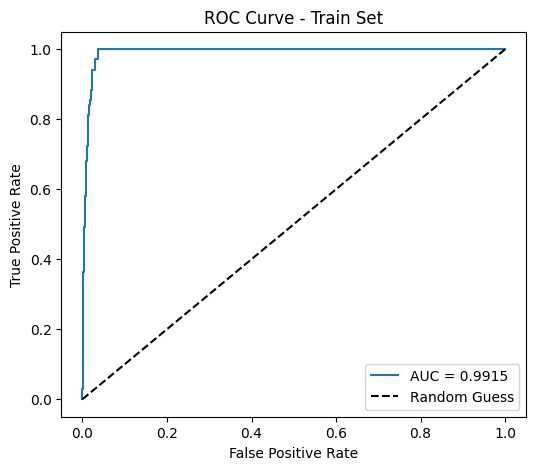

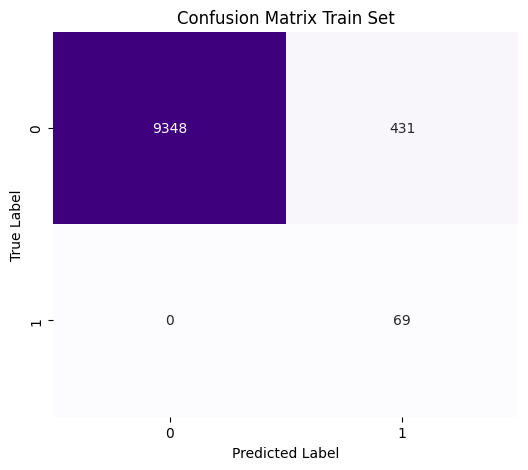

In [202]:
# Prediction and Plot metric evaluation Train Set
binary_class_pred_eval(X_train, y_train, grid_search, "Train Set")

Val Set AUC-ROC: 0.9781


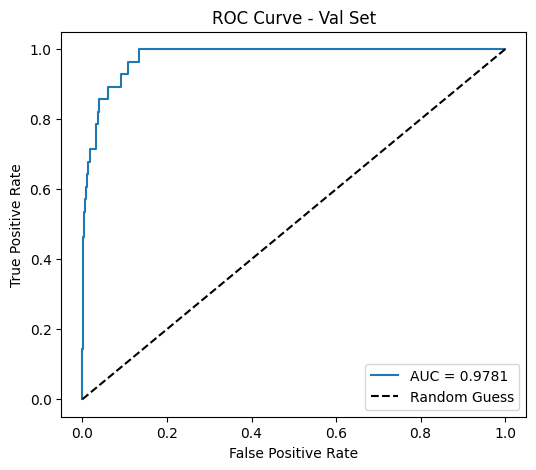

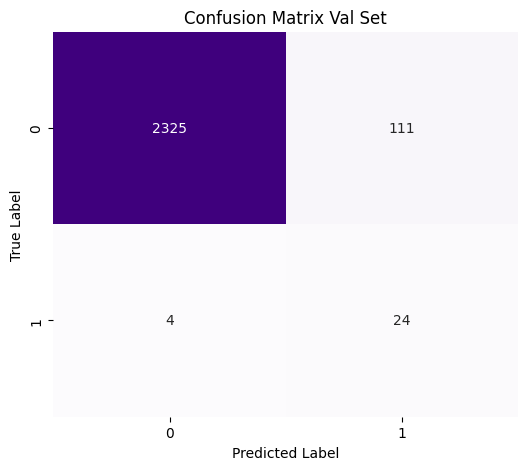

In [203]:
# Prediction and Plot metric evaluation Val Set
binary_class_pred_eval(X_val, y_val, grid_search, "Val Set")

In [204]:
# Predicting test set
y_test_prob_lr = grid_search.predict_proba(X_test)
X_test = pd.read_csv('../data/raw/test.csv')
X_test['drafted'] = y_test_prob_lr[:, 1].round(2)

X_test[['player_id', 'drafted']].to_csv('../data/processed/y_test_lr.csv', index=False)

In [206]:
# <Student to fill this section>
model_performance_explanations = """
The model selected shows good performance overall, but it incorrectly predicts non-drafted players as drafted in 111 on Val set, which is 4 times more than real drafted players (28 in total). That suggests the dataset may be too generalized and the model can't distinguish difference between non-drafted and drafted.
"""

In [207]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [208]:
# <Student to fill this section>
business_impacts_explanations = """
The current model correctly predicts drafted players in 85%, but mistakenly predicts 4 times more of that with non-drafted players as drafted. With that in mind, the current model is not safe enought to deliver business value since the high volume of 'polution' in the most desired knowledge (drafted players), which could lead to bad decision making.
"""

In [209]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [210]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [211]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [212]:
# <Student to fill this section>
experiment_results_explanations = """
The current LogisticRegression model presented sucess in predicting drafted players in 85% of the cases in validation set. However, it predicts many false negatives (non-drafted as drafted). Therefore, more experiments must be made in order to achieve better results. In case of desire to proceed with the current model, the feature rec_rank could be an important decision feature, but it needs business knowledge to fix all missing values.
"""

In [213]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)